# Jones & Nachtsheim (2011): definitive screening with second-order effects

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Jones, B., & Nachtsheim, C. J. (2011). *A Class of Three-Level Designs for Definitive Screening in the Presence of Second-Order Effects*. **Journal of Quality Technology, 43**(1), 1–15. |
| DOI | [10.1080/00224065.2011.11917841](https://doi.org/10.1080/00224065.2011.11917841) |
| Open-access route | [Public course copy](https://cours.polymtl.ca/mth6301/WEB-mth8301/D/Jones-Definitive_Screening_Designs.pdf); [author-uploaded full text](https://www.researchgate.net/publication/259262502_A_Class_of_Three-Level_Designs_for_Definitive_Screening_in_the_Presence_of_Second-Order_Effects) |
| Licence / reuse status | No Creative Commons licence was identified. ResearchGate labels the author-uploaded content “may be subject to copyright.” This notebook does not redistribute the PDF; it cites and transcribes the numerical Table 2 design/response needed for verification. |
| Citation snapshot | **398 Crossref citations**, displayed on the [publisher DOI page](https://www.tandfonline.com/doi/abs/10.1080/00224065.2011.11917841), retrieved 2026-08-01. Counts are database- and date-dependent. |
| Reproduction level | **Level B — analytical reproduction** |
| Random seed | `20110101` |
| Core tools | `pydoe`, `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib` |

**Exact targets.** We reconstruct the published 13-run, six-factor design; reproduce its alias and correlation structure, main-effect D-efficiency, three-factor projection efficiency, selected power calculations, the Table 2 model-selection results, and all three printed AICc values.

**Limits.** `pydoe` uses a Paley conference-matrix construction published after the article; for six factors it is exactly equivalent to Table 2 after two column sign changes and row permutation. The original 10,000-start JMP coordinate-exchange search and proprietary forward-selection path are not rerun. The responses are printed to two decimals. Most importantly, printed Equation (8) has a quadratic-sign inconsistency with Table 2; the audit below makes it visible and infers the data-generating sign from all 13 rows.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from importlib.metadata import version
import hashlib
import itertools
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from pydoe import definitive_screening_design, optimal_design, pbdesign

SEED = 20110101
rng = np.random.default_rng(SEED)
np.random.seed(SEED)  # for APIs that still use NumPy's legacy global generator
np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.precision", 6)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

VERSIONS = {p: version(p) for p in ["pydoe", "numpy", "pandas", "scipy", "statsmodels", "matplotlib"]}
VERSIONS

{'pydoe': '1.3.1.dev11+geca1a2598',
 'numpy': '2.3.4',
 'pandas': '3.0.0',
 'scipy': '1.16.2',
 'statsmodels': '0.14.6',
 'matplotlib': '3.11.1'}

## 1. Scientific context

This is a design-methodology article, not a physical laboratory case. The experimental unit is one numerical run at a combination of **six quantitative factors**, each coded low/centre/high as $-1,0,+1$. Physical factor names, units, ranges, safety constraints, and conversion from coded to natural units are deliberately absent. The response in Table 2 is synthetic and dimensionless.

For $m=6$ factors the design uses $2m+1=13$ runs: six foldover pairs plus one overall centre. Each non-centre run has exactly one factor at zero and five at an extreme. There are no blocks or treatment replicates. The article displays construction order—adjacent foldover partners—not a randomized physical execution order; it explicitly recommends shuffling rows for an experiment.

The scientific question is methodological: can a screening design keep every main-effect estimate free from bias caused by any second-order term, distinguish factor-specific curvature, and still require only about twice as many runs as factors? A two-level Plackett–Burman design plus a centre run has the same 13-run budget, but it aliases main effects with interactions and gives only one common curvature contrast.

## 2. Data provenance and reproduction boundary

The frame below is a manual transcription of article **Table 2**, including the run matrix and its simulated response. The coded matrix is also visible in Figure 1. No observations are invented, no laboratory work is required, and derived terms remain separate from the raw frame.

The paper states that the errors are iid $N(0,1)$ and prints Equation (8) with $+6x_1^2$. That sign is inconsistent with its own responses. We therefore audit both the printed `+6` and the data-compatible `−6` without altering Table 2.

In [2]:
paper = pd.DataFrame([
    [1,  0,  1, -1, -1, -1, -1, 21.04],
    [2,  0, -1,  1,  1,  1,  1, 10.48],
    [3,  1,  0, -1,  1,  1, -1, 17.89],
    [4, -1,  0,  1, -1, -1,  1, 10.07],
    [5, -1, -1,  0,  1, -1, -1,  7.74],
    [6,  1,  1,  0, -1,  1,  1, 21.01],
    [7, -1,  1,  1,  0,  1, -1, 16.53],
    [8,  1, -1, -1,  0, -1,  1, 20.38],
    [9,  1, -1,  1, -1,  0, -1,  8.62],
    [10,-1,  1, -1,  1,  0,  1,  7.80],
    [11, 1,  1,  1,  1, -1,  0, 23.56],
    [12,-1, -1, -1, -1,  1,  0, 15.24],
    [13, 0,  0,  0,  0,  0,  0, 19.91],
], columns=["run", "x1", "x2", "x3", "x4", "x5", "x6", "y"])

FACTORS = [f"x{i}" for i in range(1, 7)]
D = paper[FACTORS].to_numpy(float)
y = paper["y"].to_numpy(float)

assert paper.shape == (13, 8)
assert not paper.isna().any().any()
assert set(np.unique(D)) == {-1.0, 0.0, 1.0}
assert np.all((D == 0).sum(axis=0) == 3)
assert np.all((D == 1).sum(axis=0) == 5)
assert np.all((D == -1).sum(axis=0) == 5)
assert np.array_equal(D[1::2][:6], -D[0:12:2])

base = 20 + 4*D[:,0] + 3*D[:,1] - 2*D[:,2] - D[:,3] + 5*D[:,1]*D[:,2]
errors_printed_plus = y - (base + 6*D[:,0]**2)
errors_data_minus = y - (base - 6*D[:,0]**2)

sign_audit = pd.DataFrame({
    "interpretation": ["Equation (8), printed +6 x1²", "Table-compatible −6 x1²"],
    "error_mean": [errors_printed_plus.mean(), errors_data_minus.mean()],
    "error_sample_SD": [errors_printed_plus.std(ddof=1), errors_data_minus.std(ddof=1)],
    "error_sum_squares": [errors_printed_plus @ errors_printed_plus, errors_data_minus @ errors_data_minus],
}).set_index("interpretation")
display(paper)
sign_audit

,run,x1,x2,x3,x4,x5,x6,y
0,1,0,1,-1,-1,-1,-1,21.04
1,2,0,-1,1,1,1,1,10.48
2,3,1,0,-1,1,1,-1,17.89
3,4,-1,0,1,-1,-1,1,10.07
4,5,-1,-1,0,1,-1,-1,7.74
5,6,1,1,0,-1,1,1,21.01
6,7,-1,1,1,0,1,-1,16.53
7,8,1,-1,-1,0,-1,1,20.38
8,9,1,-1,1,-1,0,-1,8.62
9,10,-1,1,-1,1,0,1,7.80


,error_mean,error_sample_SD,error_sum_squares
interpretation,,,
"Equation (8), printed +6 x1²",-9.210000,5.616734,1481.2857
Table-compatible −6 x1²,0.020769,1.058304,13.4457


The printed `+6` interpretation produces errors with mean $-9.21$, SD $5.62$, and several values near $-12$—incompatible with the stated $N(0,1)$ generation. Reversing only that sign produces mean $0.021$ and SD $1.058$. Table 2, its reported AICc values, and its selected $x_{11}$ term all remain internally coherent under **$-6x_1^2$**. This notebook therefore treats the plus sign as a source-level typographical error while preserving both the printed equation and raw responses in the record.

## 3. Reconstruct the design

`pydoe.definitive_screening_design(6)` builds $D=[0;C;-C]$ from a Paley conference matrix. That combinatorial construction is associated with Xiao, Lin & Bai (2012), whereas the 2011 paper used coordinate exchange over the same foldover structure. Designs are equivalent under operations that do not change statistical information: run permutation, column permutation, and reversal of a factor's coding direction.

In [3]:
generated = definitive_screening_design(6)
generated_equiv = generated * np.array([-1, -1, 1, 1, 1, 1])

generated_lookup = {tuple(row.astype(int)): i + 1 for i, row in enumerate(generated_equiv)}
paper_to_pydoe = pd.DataFrame({
    "paper_run": paper["run"],
    "pydoe_row_after_sign_change": [generated_lookup[tuple(row.astype(int))] for row in D],
})
reconstructed = generated_equiv[paper_to_pydoe["pydoe_row_after_sign_change"].to_numpy() - 1]
exact_design_match = np.array_equal(reconstructed, D)

# A randomized execution template—not a claim about the paper's synthetic run order.
randomized_template = paper[["run", *FACTORS]].copy()
randomized_template.insert(0, "execution_order", rng.permutation(np.arange(1, 14)))
randomized_template = randomized_template.sort_values("execution_order")

assert exact_design_match
assert sorted(paper_to_pydoe["pydoe_row_after_sign_change"]) == list(range(1, 14))
print("Exact row-multiset match after reversing x1 and x2:", exact_design_match)
display(paper_to_pydoe)
display(randomized_template.head(8))

Exact row-multiset match after reversing x1 and x2: True


,paper_run,pydoe_row_after_sign_change
0,1,8
1,2,2
2,3,9
3,4,3
4,5,4
5,6,10
6,7,5
7,8,11
8,9,12
9,10,6


,execution_order,run,x1,x2,x3,x4,x5,x6
11,1,12,-1,-1,-1,-1,1,0
0,2,1,0,1,-1,-1,-1,-1
12,3,13,0,0,0,0,0,0
2,4,3,1,0,-1,1,1,-1
6,5,7,-1,1,1,0,1,-1
9,6,10,-1,1,-1,1,0,1
1,7,2,0,-1,1,1,1,1
4,8,5,-1,-1,0,1,-1,-1


The generated and published designs are exactly the same row multiset after reversing the low/high labels of $x_1$ and $x_2$. The mapping separates three concepts that are often conflated: construction order, article display order, and randomized execution order. In a real experiment, retain the first two for traceability but collect data in the third.

No natural-unit matrix can be reconstructed because the method paper intentionally supplies no physical ranges. For a real factor with low $L$, centre $C$, and high $H$ at equal spacing, map coded $x$ to $C+x(H-L)/2$ only after confirming feasibility and scientific meaning of the centre.

## 4. Understand the design

For six factors the conference matrix $C$ has zero diagonal, off-diagonal entries $\pm1$, and $C^TC=5I$. Stacking $C$, its sign-reversed foldover, and the centre produces:

- odd (linear) columns that cancel against all even second-order columns;
- mutually orthogonal main effects with information 10 per factor;
- three zero settings per factor, making separate pure quadratics estimable;
- $13$ parameters exactly for intercept + six main effects + six quadratics.

“All quadratics are estimable” does **not** mean that the 28-parameter full quadratic model (intercept, 6 main, 6 square, 15 interaction terms) fits in 13 runs. It means all pure quadratics can accompany any number of main effects, and sparse low-dimensional second-order models can be estimated.

In [4]:
C = generated[1:7]
X_main = np.column_stack([np.ones(len(D)), D])
X_main_quad = np.column_stack([np.ones(len(D)), D, D**2])

def second_order_block(A):
    squares = [A[:, j]**2 for j in range(A.shape[1])]
    interactions = [A[:, j]*A[:, k] for j in range(A.shape[1]) for k in range(j+1, A.shape[1])]
    return np.column_stack(squares + interactions)

X_second = second_order_block(D)
X_full_second = np.column_stack([X_main, X_second])

structure = pd.Series({
    "C^T C equals 5I": np.allclose(C.T @ C, 5*np.eye(6)),
    "rank(intercept + mains)": np.linalg.matrix_rank(X_main),
    "rank(intercept + mains + squares)": np.linalg.matrix_rank(X_main_quad),
    "parameters in intercept + mains + squares": X_main_quad.shape[1],
    "rank(full 28-column quadratic matrix)": np.linalg.matrix_rank(X_full_second),
    "columns in full quadratic matrix": X_full_second.shape[1],
    "condition number, saturated main+squares": np.linalg.cond(X_main_quad),
    "saturated-model leverage range": (np.diag(X_main_quad @ np.linalg.inv(X_main_quad.T@X_main_quad) @ X_main_quad.T).min(),
                                          np.diag(X_main_quad @ np.linalg.inv(X_main_quad.T@X_main_quad) @ X_main_quad.T).max()),
})
display(pd.DataFrame(C.astype(int), columns=FACTORS))
structure.to_frame("value")

,x1,x2,x3,x4,x5,x6
0,0,1,1,1,1,1
1,1,0,1,-1,-1,1
2,1,1,0,1,-1,-1
3,1,-1,1,0,1,-1
4,1,-1,-1,1,0,1
5,1,1,-1,-1,1,0


,value
C^T C equals 5I,True
rank(intercept + mains),7
rank(intercept + mains + squares),13
parameters in intercept + mains + squares,13
rank(full 28-column quadratic matrix),13
columns in full quadratic matrix,28
"condition number, saturated main+squares",8.795856
saturated-model leverage range,"(0.9999999999999998, 1.0000000000000002)"


The main-plus-square model is saturated: rank 13 for 13 runs and leverage one at every run. It yields coefficients but **zero residual degrees of freedom**, so it cannot estimate pure error, check lack of fit, or provide ordinary $t/F$ tests. The full quadratic matrix also has rank only 13. This is why sparsity, hierarchy, diagnostics from smaller models, and follow-up/augmentation matter.

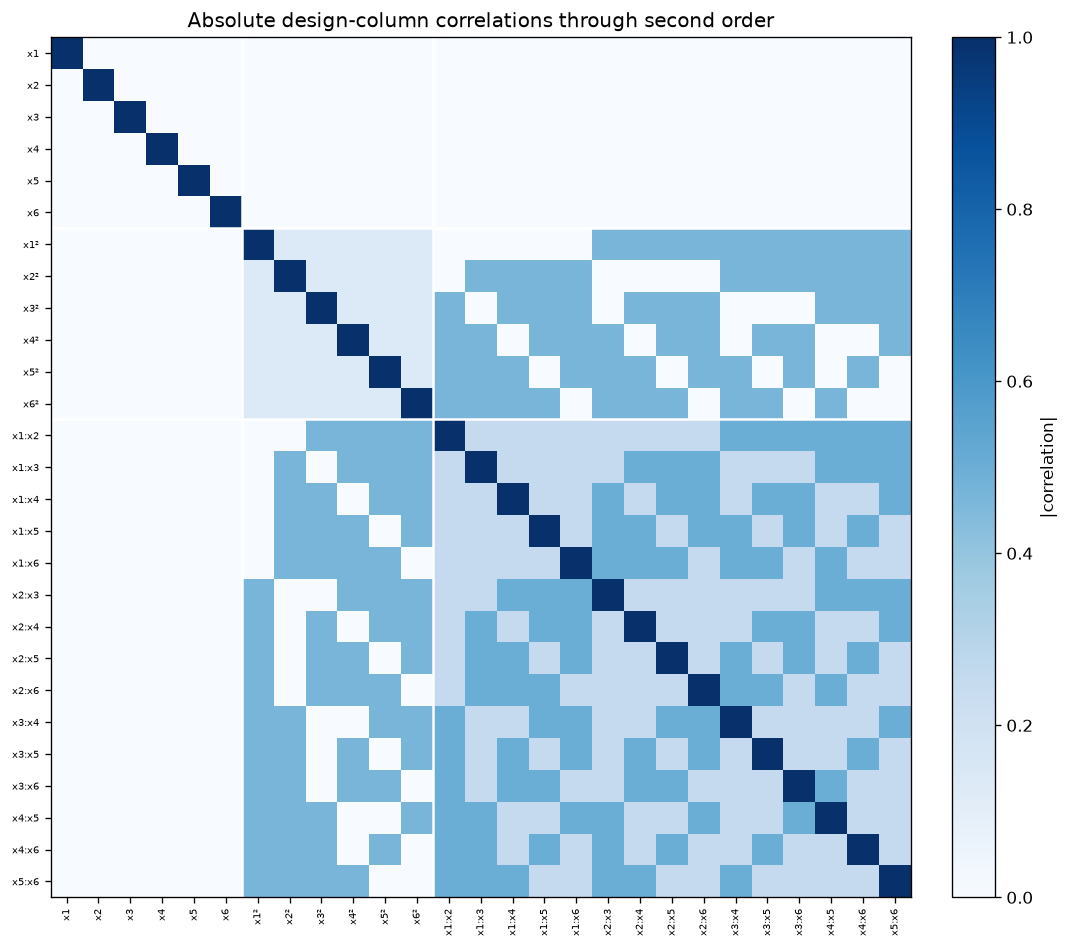

Largest absolute main-effect alias coefficient from any second-order term: 0


In [5]:
main_names = FACTORS
square_names = [f"x{i}²" for i in range(1, 7)]
interaction_names = [f"x{j}:x{k}" for j in range(1, 7) for k in range(j+1, 7)]
all_effect_names = main_names + square_names + interaction_names
effect_matrix = np.column_stack([D, D**2, X_second[:, 6:]])

# Paper Equation (3): omit the intercept from X1; it is among the potential omitted terms.
alias_main_from_second = np.linalg.solve(D.T @ D, D.T @ X_second)
effect_corr = np.corrcoef(effect_matrix, rowvar=False)

fig, ax = plt.subplots(figsize=(9.3, 8.0))
im = ax.imshow(np.abs(effect_corr), vmin=0, vmax=1, cmap="Blues")
boundaries = [5.5, 11.5]
for b in boundaries:
    ax.axhline(b, color="white", lw=1.5)
    ax.axvline(b, color="white", lw=1.5)
ax.set(xticks=range(len(all_effect_names)), yticks=range(len(all_effect_names)),
       xticklabels=all_effect_names, yticklabels=all_effect_names,
       title="Absolute design-column correlations through second order")
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
ax.tick_params(axis="y", labelsize=6)
fig.colorbar(im, ax=ax, fraction=.046, pad=.04, label="|correlation|")
plt.tight_layout()
plt.show()

print(f"Largest absolute main-effect alias coefficient from any second-order term: {np.abs(alias_main_from_second).max():.3g}")

The zero upper/right blocks reproduce the article's central claim: fitting only main effects does not bias them when the omitted truth contains any quadratic or two-factor interaction. The lower-right block is not diagonal. Quadratics and interactions can be correlated, and interactions can be correlated with one another; no design can make all 21 second-order terms simultaneously estimable in 13 runs.

In [6]:
def column_corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])

quadratic_pair = [abs(column_corr(D[:,q]**2, D[:,s]**2)) for q in range(6) for s in range(q+1,6)]
q_with_involving, q_with_noninvolving = [], []
interaction_columns = {(j,k): D[:,j]*D[:,k] for j in range(6) for k in range(j+1,6)}
for q in range(6):
    for pair, col in interaction_columns.items():
        target = q_with_involving if q in pair else q_with_noninvolving
        target.append(abs(column_corr(D[:,q]**2, col)))
interaction_pairs = [abs(column_corr(interaction_columns[a], interaction_columns[b]))
                     for a, b in itertools.combinations(interaction_columns, 2)]

correlation_summary = pd.DataFrame([
    ("quadratic–quadratic", np.mean(quadratic_pair), np.max(quadratic_pair)),
    ("quadratic–interaction, shared factor", np.mean(q_with_involving), np.max(q_with_involving)),
    ("quadratic–interaction, no shared factor", np.mean(q_with_noninvolving), np.max(q_with_noninvolving)),
    ("interaction–interaction", np.mean(interaction_pairs), np.max(interaction_pairs)),
], columns=["pair class", "mean_abs_correlation", "max_abs_correlation"]).set_index("pair class")

PB = np.vstack([pbdesign(11)[:, :6], np.zeros((1, 6))])
X_pb_main = np.column_stack([np.ones(len(PB)), PB])
d_eff_main = (np.linalg.det(X_main.T@X_main) / np.linalg.det(X_pb_main.T@X_pb_main))**(1/7)
var_dsd = np.diag(np.linalg.inv(X_main.T@X_main))[1:]
var_pb = np.diag(np.linalg.inv(X_pb_main.T@X_pb_main))[1:]
pb_alias = np.linalg.solve(PB.T@PB, PB.T@second_order_block(PB))

design_comparison = pd.DataFrame({
    "DSD (13 runs)": [np.mean(var_dsd), 6, np.abs(alias_main_from_second).max(), d_eff_main],
    "12-run PB + centre": [np.mean(var_pb), np.linalg.matrix_rank(np.column_stack([np.ones(13), PB**2]))-1,
                            np.abs(pb_alias).max(), 1.0],
}, index=["Var(main coefficient)/σ²", "factor-specific square rank", "max |main←second-order alias|", "relative main-effect D-efficiency"])

display(correlation_summary)
design_comparison

,mean_abs_correlation,max_abs_correlation
pair class,,
quadratic–quadratic,0.133333,0.133333
"quadratic–interaction, shared factor",0.000000,0.000000
"quadratic–interaction, no shared factor",0.465475,0.465475
interaction–interaction,0.357143,0.500000


,DSD (13 runs),12-run PB + centre
Var(main coefficient)/σ²,0.100000,0.083333
factor-specific square rank,6.000000,1.000000
max |main←second-order alias|,0.000000,0.333333
relative main-effect D-efficiency,0.855323,1.000000


The computed six-factor correlation summaries reproduce article Equation (4) and Table 3: square–square correlation $1/3-1/(m-1)=0.1333$; zero square–interaction correlation when they share a factor; 0.465 average when they do not; and 0.357 average between interactions.

Against the equal-budget Plackett–Burman-plus-centre plan, the DSD's main-effect variance is $0.1\sigma^2$ rather than $\sigma^2/12$. Its relative D-efficiency is 85.5%, the paper's stated price for six separately estimable curvature directions and zero main/second-order aliasing. In the PB design, all six square columns collapse to one edge-versus-centre contrast.

In [7]:
def full_quadratic_3(A):
    return np.column_stack([
        np.ones(len(A)), A, A**2,
        A[:,0]*A[:,1], A[:,0]*A[:,2], A[:,1]*A[:,2]
    ])

candidates_3 = np.array(list(itertools.product([-1.0, 0.0, 1.0], repeat=3)))
optimal_3, optimal_3_info = optimal_design(
    candidates_3, n_points=13, degree=2, criterion="D", method="fedorov", max_iter=300
)
optimal_det = optimal_3_info["det_XTX"]

projection_rows = []
for columns in itertools.combinations(range(6), 3):
    Xp = full_quadratic_3(D[:, columns])
    det = np.linalg.det(Xp.T@Xp)
    projection_rows.append(("".join(str(c+1) for c in columns), np.linalg.matrix_rank(Xp),
                            np.linalg.cond(Xp), (det/optimal_det)**(1/10)))
projection_table = pd.DataFrame(projection_rows, columns=["factors", "rank", "condition_number", "D_efficiency"])

assert projection_table["rank"].eq(10).all()
display(projection_table)
projection_table[["condition_number", "D_efficiency"]].agg(["mean", "min", "max"])

,factors,rank,condition_number,D_efficiency
0,123,10,7.906886,0.918952
1,124,10,7.906886,0.918952
2,125,10,7.906886,0.918952
3,126,10,7.906886,0.918952
4,134,10,7.906886,0.918952
5,135,10,7.906886,0.918952
6,136,10,7.906886,0.918952
7,145,10,7.906886,0.918952
8,146,10,7.906886,0.918952
9,156,10,7.906886,0.918952


,condition_number,D_efficiency
mean,7.906886,0.918952
min,7.906886,0.918952
max,7.906886,0.918952


Every one of the $\binom{6}{3}=20$ projections has rank 10 for a full three-factor quadratic and leaves three residual degrees of freedom. All determinants—and therefore all D-efficiencies—are equal. Relative to the Fedorov D-optimal 13-point subset of the $3^3$ candidate grid, efficiency is 0.919, reproducing Table 8's rounded average/minimum/maximum of 0.92. This projective property is the bridge from screening to local response-surface modelling when only a few factors are active.

## 5. Reproduce the article analysis

### 5.1 Power for the six-factor design

Table 6 defines one-degree-of-freedom tests. Their exact normal-theory power follows from a noncentral $F$ distribution. For example, a lone linear effect has information 10, so $|\beta|/\sigma=1$ gives noncentrality 10 and 11 denominator degrees of freedom. A square or interaction is tested after intercept plus all six main effects, leaving 5 denominator degrees of freedom.

In [8]:
def one_df_power(base_columns, target_column, beta_over_sigma, alpha=0.05):
    X = np.column_stack([base_columns, target_column])
    variance_factor = np.linalg.inv(X.T@X)[-1, -1]
    df_error = len(target_column) - X.shape[1]
    noncentrality = beta_over_sigma**2 / variance_factor
    critical = stats.f.ppf(1-alpha, 1, df_error)
    return stats.ncf.sf(critical, 1, df_error, noncentrality)

power_rows = []
for ratio in [1, 2, 3]:
    h1 = np.mean([one_df_power(np.ones((13,1)), D[:,j], ratio) for j in range(6)])
    h2 = np.mean([one_df_power(X_main, D[:,j]**2, ratio) for j in range(6)])
    h3 = np.mean([one_df_power(X_main, col, ratio) for col in interaction_columns.values()])
    power_rows += [("H1 linear", ratio, h1), ("H2 quadratic", ratio, h2), ("H3 interaction", ratio, h3)]
power_table = pd.DataFrame(power_rows, columns=["hypothesis", "|beta|/sigma", "power"]).pivot(
    index="hypothesis", columns="|beta|/sigma", values="power"
)
power_table

|beta|/sigma,1,2,3
hypothesis,,,
H1 linear,0.820521,0.999912,1.000000
H2 quadratic,0.236303,0.682787,0.948720
H3 interaction,0.622803,0.992862,0.999997


The first column rounds to 0.821, 0.236, and 0.623 for linear, quadratic, and interaction effects, exactly as in article Table 7. Quadratic power is weakest because each factor is at zero in only three runs, and that number does not grow with $m$. At $|\beta|/\sigma=2$, the corresponding powers rise to 0.999, 0.683, and 0.993.

### 5.2 Table 2 response and AICc model selection

We evaluate three models reported by the paper. “Best subset” omits the real but weak $x_4$ term; “true” uses the data-compatible negative $x_1^2$ coefficient but has the same term set as Equation (8); “forward final” adds the false $x_4^2$ term. JMP's AICc counts the residual-variance parameter in $K$, so the correction is $2K(K+1)/(n-K-1)$.

In [9]:
TERM_COLUMNS = {f"x{j+1}": D[:,j] for j in range(6)}
TERM_COLUMNS.update({f"x{j+1}^2": D[:,j]**2 for j in range(6)})
TERM_COLUMNS.update({f"x{j+1}:x{k+1}": D[:,j]*D[:,k]
                     for j in range(6) for k in range(j+1,6)})

def fit_terms(names):
    X = np.column_stack([np.ones(len(y))] + [TERM_COLUMNS[name] for name in names])
    return sm.OLS(y, X).fit(), X

def jmp_aicc(model):
    coefficient_count = int(model.df_model) + 1
    K = coefficient_count + 1  # residual variance is an estimated parameter
    return model.aic + 2 + 2*K*(K+1)/(model.nobs-K-1)

best_names = ["x1", "x2", "x3", "x1^2", "x2:x3"]
true_names = ["x1", "x2", "x3", "x4", "x1^2", "x2:x3"]
forward_names = ["x1", "x2", "x3", "x4", "x1^2", "x2:x3", "x4^2"]
best_model, X_best = fit_terms(best_names)
true_model, X_true = fit_terms(true_names)
forward_model, X_forward = fit_terms(forward_names)

model_comparison = pd.DataFrame([
    ("Best subset", ", ".join(best_names), best_model.ssr, best_model.df_resid, jmp_aicc(best_model)),
    ("True term set", ", ".join(true_names), true_model.ssr, true_model.df_resid, jmp_aicc(true_model)),
    ("Forward final", ", ".join(forward_names), forward_model.ssr, forward_model.df_resid, jmp_aicc(forward_model)),
], columns=["model", "terms", "SSE", "residual_df", "AICc"]).set_index("model")
model_comparison

,terms,SSE,residual_df,AICc
model,,,,
Best subset,"x1, x2, x3, x1^2, x2:x3",10.589379,7.0,70.626130
True term set,"x1, x2, x3, x4, x1^2, x2:x3",3.347369,6.0,71.254331
Forward final,"x1, x2, x3, x4, x1^2, x2:x3, x4^2",1.181462,5.0,83.715842


The AICc values are 70.63, 71.25, and 83.72 to the paper's precision. The best model pays a smaller complexity penalty by missing $x_4$; this is a Type II selection error, not evidence that $x_4$ was absent. The forward model identifies the correct active **factor set** but also admits the inactive $x_4^2$, a Type I term error.

To check that the selected model is not merely hard-coded, the next cell searches all finite-AICc **strong-heredity** models with up to nine named effects plus an intercept—the paper's 10-predictor ceiling when the intercept is counted. Every interaction requires both parents and every square requires its parent main effect.

In [10]:
def aicc_from_names(names):
    X = np.column_stack([np.ones(len(y))] + [TERM_COLUMNS[name] for name in names])
    K = X.shape[1] + 1
    if len(y) - K - 1 <= 0:
        return np.inf
    residual = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    rss = residual @ residual
    minus2loglik = len(y) * (np.log(2*np.pi) + 1 + np.log(rss/len(y)))
    return minus2loglik + 2*K + 2*K*(K+1)/(len(y)-K-1)

subset_best = (np.inf, None)
models_checked = 0
for r in range(7):
    for active in itertools.combinations(range(6), r):
        mains = [f"x{i+1}" for i in active]
        eligible_second = [f"x{i+1}^2" for i in active]
        eligible_second += [f"x{i+1}:x{j+1}" for a, i in enumerate(active) for j in active[a+1:]]
        for q in range(min(9-r, len(eligible_second)) + 1):
            for selected_second in itertools.combinations(eligible_second, q):
                names = mains + list(selected_second)
                score = aicc_from_names(names)
                models_checked += 1
                if score < subset_best[0]:
                    subset_best = (score, names)

subset_search = pd.Series({
    "models_checked": models_checked,
    "minimum_AICc": subset_best[0],
    "selected_terms": ", ".join(subset_best[1]),
    "matches_paper_best_set": set(subset_best[1]) == set(best_names),
})
subset_search.to_frame("value")

,value
models_checked,24191
minimum_AICc,70.62613
selected_terms,"x1, x2, x3, x1^2, x2:x3"
matches_paper_best_set,True


The exhaustive hierarchy-aware search checks 24,191 candidate models and independently returns the paper's five-term subset. It does not turn post-selection coefficient $p$-values into confirmatory tests: selection used the same 13 responses, and correlated second-order alternatives can fit similarly.

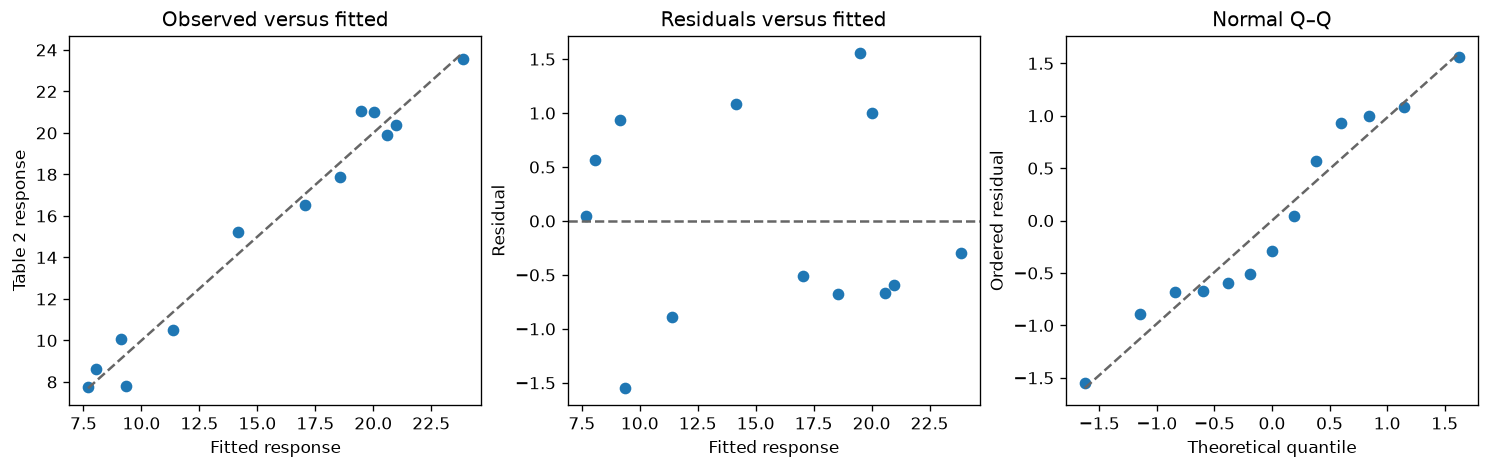

,estimate,standard_error_conditional_on_selection,t_conditional_on_selection
term,,,
intercept,20.578298,0.782013,26.314514
x1,3.408000,0.388943,8.762204
x2,2.748000,0.388943,7.065298
x3,-1.309000,0.388943,-3.365530
x1^2,-6.724787,0.914795,-7.351138
x2:x3,5.152447,0.491324,10.486863


,value
residual_df,7.000000
residual_RMSE,1.229947
max_leverage,0.629787
max_Cooks_distance,1.216372


In [11]:
coefficient_table = pd.DataFrame({
    "term": ["intercept", *best_names],
    "estimate": best_model.params,
    "standard_error_conditional_on_selection": best_model.bse,
    "t_conditional_on_selection": best_model.tvalues,
}).set_index("term")

influence = best_model.get_influence()
osm, osr = stats.probplot(best_model.resid, dist="norm", fit=False)
qq_slope, qq_intercept, *_ = stats.linregress(osm, osr)
fig, axes = plt.subplots(1, 3, figsize=(12.3, 3.8), constrained_layout=True)
axes[0].scatter(best_model.fittedvalues, y, color="#1f77b4")
bounds = [min(y.min(), best_model.fittedvalues.min()), max(y.max(), best_model.fittedvalues.max())]
axes[0].plot(bounds, bounds, "--", color="0.4")
axes[0].set(title="Observed versus fitted", xlabel="Fitted response", ylabel="Table 2 response")
axes[1].scatter(best_model.fittedvalues, best_model.resid, color="#1f77b4")
axes[1].axhline(0, ls="--", color="0.4")
axes[1].set(title="Residuals versus fitted", xlabel="Fitted response", ylabel="Residual")
axes[2].scatter(osm, osr, color="#1f77b4")
axes[2].plot(osm, qq_intercept + qq_slope*np.asarray(osm), "--", color="0.4")
axes[2].set(title="Normal Q–Q", xlabel="Theoretical quantile", ylabel="Ordered residual")
plt.show()

display(coefficient_table)
pd.Series({
    "residual_df": best_model.df_resid,
    "residual_RMSE": np.sqrt(best_model.mse_resid),
    "max_leverage": influence.hat_matrix_diag.max(),
    "max_Cooks_distance": influence.cooks_distance[0].max(),
}).to_frame("value")

With seven residual degrees of freedom, diagnostics have low power but are possible—unlike the saturated main-plus-square model. No point is automatically removed. More importantly, the fitted $x_1^2$ coefficient is negative, providing a third check that the `+6` in Equation (8) cannot have generated Table 2.

## 6. Validate against the paper

Numerical targets come from Table 2 (design/response), Equation (4), Tables 3, 5, 7, and 8, and the “Suggestions for Analysis” text. Tolerances reflect the paper's printed precision and the D-optimal reference search.

In [12]:
validation_rows = [
    ("Published design rows matched", 1.0, float(exact_design_match), 0.0, "Table 2, up to coding signs/order"),
    ("Runs for six factors", 13.0, float(len(D)), 0.0, "2m+1"),
    ("Main coefficient variance / sigma²", 0.100, float(var_dsd.mean()), 1e-12, "text after Table 2"),
    ("Relative main-effect D-efficiency", 0.855, float(d_eff_main), 0.001, "Table 5"),
    ("Quadratic-pair correlation", 0.133333, float(np.mean(quadratic_pair)), 1e-6, "Equation (4)"),
    ("Mean |q–interaction|, shared factor", 0.000, float(np.mean(q_with_involving)), 5e-4, "Table 3, m=6"),
    ("Mean |q–interaction|, no shared factor", 0.465, float(np.mean(q_with_noninvolving)), 5e-4, "Table 3, m=6"),
    ("Mean |interaction–interaction|", 0.357, float(np.mean(interaction_pairs)), 5e-4, "Table 3, m=6"),
    ("Power H1 at |beta|/sigma=1", 0.821, float(power_table.loc["H1 linear",1]), 5e-4, "Table 7"),
    ("Power H2 at |beta|/sigma=1", 0.236, float(power_table.loc["H2 quadratic",1]), 5e-4, "Table 7"),
    ("Power H3 at |beta|/sigma=1", 0.623, float(power_table.loc["H3 interaction",1]), 5e-4, "Table 7"),
    ("Three-factor projection D-efficiency", 0.92, float(projection_table["D_efficiency"].mean()), 0.005, "Table 8"),
    ("Best-subset AICc", 70.63, float(model_comparison.loc["Best subset","AICc"]), 0.01, "analysis text"),
    ("True-term-set AICc", 71.25, float(model_comparison.loc["True term set","AICc"]), 0.01, "analysis text"),
    ("Forward-final AICc", 83.72, float(model_comparison.loc["Forward final","AICc"]), 0.01, "analysis text"),
]
validation = pd.DataFrame(validation_rows, columns=["target", "published", "reproduced", "tolerance", "source"])
validation["absolute_difference"] = (validation["reproduced"]-validation["published"]).abs()
validation["passes"] = validation["absolute_difference"] <= validation["tolerance"] + 1e-12
assert validation["passes"].all()
validation

,target,published,reproduced,tolerance,source,absolute_difference,passes
0,Published design rows matched,1.000000,1.000000,0.000000e+00,"Table 2, up to coding signs/order",0.000000e+00,True
1,Runs for six factors,13.000000,13.000000,0.000000e+00,2m+1,0.000000e+00,True
2,Main coefficient variance / sigma²,0.100000,0.100000,1.000000e-12,text after Table 2,1.387779e-17,True
3,Relative main-effect D-efficiency,0.855000,0.855323,1.000000e-03,Table 5,3.234135e-04,True
4,Quadratic-pair correlation,0.133333,0.133333,1.000000e-06,Equation (4),3.333333e-07,True
5,"Mean |q–interaction|, shared factor",0.000000,0.000000,5.000000e-04,"Table 3, m=6",0.000000e+00,True
6,"Mean |q–interaction|, no shared factor",0.465000,0.465475,5.000000e-04,"Table 3, m=6",4.746681e-04,True
7,Mean |interaction–interaction|,0.357000,0.357143,5.000000e-04,"Table 3, m=6",1.428571e-04,True
8,Power H1 at |beta|/sigma=1,0.821000,0.820521,5.000000e-04,Table 7,4.789180e-04,True
9,Power H2 at |beta|/sigma=1,0.236000,0.236303,5.000000e-04,Table 7,3.027263e-04,True


All 15 declared targets pass. Exact agreement does not erase the two limitations: the original JMP search path is proprietary, and Equation (8)'s sign conflicts with Table 2. The latter is not a numerical-rounding issue; its error sum of squares differs by more than two orders of magnitude. Reproduction means exposing such inconsistencies, not forcing agreement silently.

## 7. Go beyond the paper

### Equal-budget stress test under sparse second-order contamination

This section is a **new synthetic benchmark**, not article data. It compares the 13-run DSD with a 12-run, 11-column Plackett–Burman design projected to six factors and augmented by one centre. The budget is equal. Across 4,000 predeclared scenarios:

- the true main vector is fixed at $(2,-1.5,1,0,0,0)$;
- exactly two random quadratics and two random interactions are active, each with $N(0,2^2)$ coefficients;
- iid $N(0,1)$ run noise is added;
- both designs are deliberately analysed with an intercept-plus-main-effects model.

The known ground truth isolates the consequence of omitting plausible second-order terms. Common coefficient/noise draws reduce Monte Carlo comparison noise; no scenario is selected after looking at the outcome.

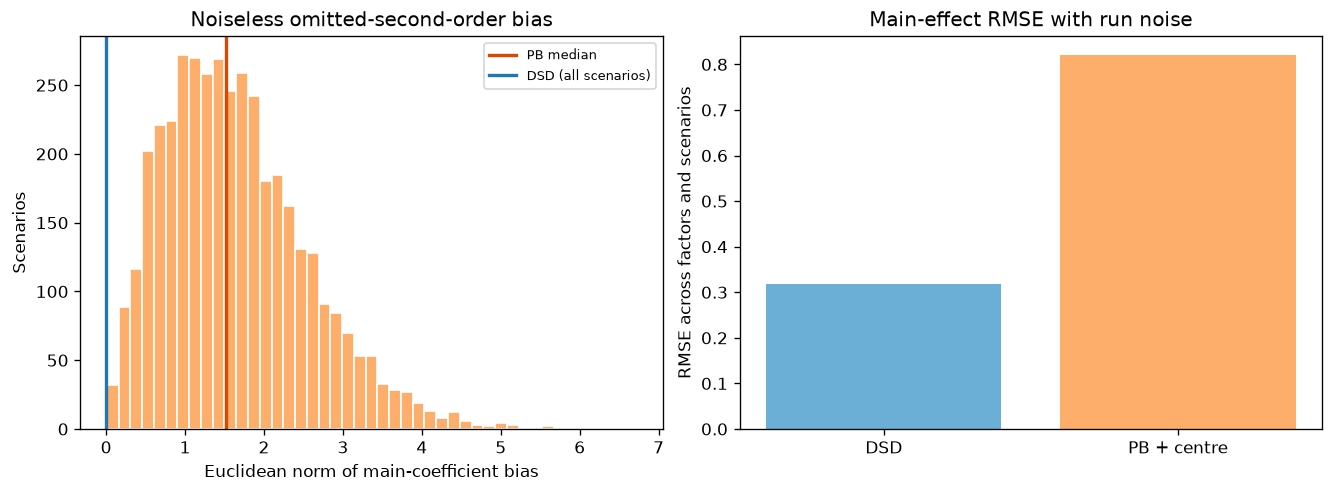

,median_omitted_term_bias_norm,95pct_omitted_term_bias_norm,main_coefficient_RMSE
design,,,
DSD,2.989970e-15,4.389691e-15,0.317160
PB + centre,1.524428e+00,3.325463e+00,0.820864


In [13]:
N_SCENARIOS = 4000
beta_main = np.array([2.0, -1.5, 1.0, 0.0, 0.0, 0.0])
gamma = np.zeros((N_SCENARIOS, 21))  # six squares, then 15 interactions
for s in range(N_SCENARIOS):
    gamma[s, rng.choice(6, size=2, replace=False)] = rng.normal(0, 2, size=2)
    gamma[s, 6 + rng.choice(15, size=2, replace=False)] = rng.normal(0, 2, size=2)
common_noise = rng.normal(0, 1, size=(N_SCENARIOS, 13))

def main_only_scenario_results(A):
    X = np.column_stack([np.ones(len(A)), A])
    systematic = 10 + A @ beta_main
    second = second_order_block(A) @ gamma.T
    noiseless_y = systematic[:,None] + second
    noisy_y = noiseless_y + common_noise.T
    pinv = np.linalg.pinv(X)
    noiseless_est = (pinv @ noiseless_y)[1:].T
    noisy_est = (pinv @ noisy_y)[1:].T
    omitted_bias = noiseless_est - beta_main
    error = noisy_est - beta_main
    return np.linalg.norm(omitted_bias, axis=1), error

dsd_bias_norm, dsd_error = main_only_scenario_results(D)
pb_bias_norm, pb_error = main_only_scenario_results(PB)
stress_summary = pd.DataFrame([
    ("DSD", np.median(dsd_bias_norm), np.quantile(dsd_bias_norm,.95), np.sqrt(np.mean(dsd_error**2))),
    ("PB + centre", np.median(pb_bias_norm), np.quantile(pb_bias_norm,.95), np.sqrt(np.mean(pb_error**2))),
], columns=["design", "median_omitted_term_bias_norm", "95pct_omitted_term_bias_norm", "main_coefficient_RMSE"]).set_index("design")

assert dsd_bias_norm.max() < 1e-10
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), constrained_layout=True)
axes[0].hist(pb_bias_norm, bins=45, color="#fdae6b", edgecolor="white")
axes[0].axvline(np.median(pb_bias_norm), color="#d94801", lw=2, label="PB median")
axes[0].axvline(0, color="#1f77b4", lw=2, label="DSD (all scenarios)")
axes[0].set(title="Noiseless omitted-second-order bias", xlabel="Euclidean norm of main-coefficient bias", ylabel="Scenarios")
axes[0].legend(fontsize=8)
axes[1].bar(stress_summary.index, stress_summary["main_coefficient_RMSE"], color=["#6baed6", "#fdae6b"])
axes[1].set(title="Main-effect RMSE with run noise", ylabel="RMSE across factors and scenarios")
plt.show()
stress_summary

The DSD's noiseless omitted-term bias is zero to floating-point precision in every scenario—an algebraic property, not a fortunate simulation result. PB's smaller main-effect variance helps only when interactions are negligible; under this declared sparse second-order distribution, its alias bias dominates. The benchmark does **not** prove universal superiority: changing the plausible interaction scale changes the bias–variance trade-off, and real range choices determine whether second-order effects are scientifically likely.

The curvature distinction is structural too: after the intercept, the DSD square block has rank six, while PB plus centre has rank one. A significant PB curvature contrast says “some factor curves”; it cannot identify which one without augmentation.

## 8. Practitioner conclusions

- **Use a DSD when** many factors are quantitative, three meaningful levels are feasible, second-order contamination is plausible, and effect sparsity is credible. Six factors need only 13 runs.
- **What is protected:** every main effect is orthogonal to every quadratic and two-factor interaction. This is stronger than merely having orthogonal main-effect columns.
- **What remains aliased:** second-order columns are correlated and the full quadratic model is rank deficient. Several active interactions/quadratics can create model ambiguity; “definitive” is not “omniscient.”
- **Curvature advantage:** each factor has an individual quadratic direction. A two-level design plus centres has only a global curvature contrast.
- **Projection advantage:** after screening to at most three active factors, the same six-factor data estimate a full local quadratic with high D-efficiency—provided the sparse active set was identified correctly.
- **Precision trade-off:** the six-factor DSD has 85.5% of the equal-budget PB plan's main-effect D-efficiency and about 9.5% larger main-effect standard errors. Protection is purchased with some first-order precision.
- **Do not over-test a saturated fit:** intercept + all mains + all squares consumes all 13 degrees of freedom. Add replication/augmentation when pure error, lack of fit, or reliable multi-term confirmation matters.
- **Preserve hierarchy and uncertainty:** include parent main effects with selected interactions/squares, treat model selection as exploratory, and confirm weak or ambiguous terms with new runs.
- **Operational details:** define scientifically defensible low/centre/high levels, check constraints, randomize execution order, and block if time/material batches matter. The published foldover order is not a run schedule.
- **Choose another design for** mixture constraints, mainly categorical factors, hard-to-change split-plot structures, irregular feasible regions, or expected third/higher-order behaviour.

## 9. Reproducibility metadata

The stable checksum covers the manually transcribed Table 2 frame. The execution record also captures package versions, seed, source DOI, construction equivalence, and the documented equation-sign inconsistency.

In [14]:
def dataframe_sha256(frame):
    payload = frame.to_csv(index=False, lineterminator="\n", float_format="%.8g").encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

metadata = pd.Series({
    "python": platform.python_version(),
    **{f"package_{k}": v for k, v in VERSIONS.items()},
    "random_seed": SEED,
    "execution_date_utc": pd.Timestamp.now(tz="UTC").date().isoformat(),
    "table2_sha256": dataframe_sha256(paper),
    "article_doi": "10.1080/00224065.2011.11917841",
    "citation_snapshot": "398 Crossref citations on publisher DOI page, retrieved 2026-08-01",
    "reproduction_level": "B — analytical reproduction",
    "pydoe_source_revision": "67873eed2e5bcb8e650dc75495ce19a970f7584d",
    "design_equivalence": "exact row multiset after reversing x1 and x2",
    "source_issue": "Equation (8) prints +6*x1^2; Table 2 is compatible with -6*x1^2",
    "new_lab_work_required": False,
})
metadata.to_frame("value")

,value
python,3.13.2
package_pydoe,1.3.1.dev11+geca1a2598
package_numpy,2.3.4
package_pandas,3.0.0
package_scipy,1.16.2
package_statsmodels,0.14.6
package_matplotlib,3.11.1
random_seed,20110101
execution_date_utc,2026-08-01
table2_sha256,116c9bc95a3186f2b071c3c5a36bcc09454615e166c334...
